# Chapter 10 example: Chow--Liu structure learning

This notebook turns the tree factorization from Chapters 2--3 into a learning algorithm. We generate samples from a binary Ising model whose interaction graph is a tree, estimate all pairwise mutual informations, and reconstruct the maximum-weight spanning tree.

For a tree-structured distribution $P_T$, the Chow--Liu projection minimizes $D_{\mathrm{KL}}(P\Vert P_T)$ by maximizing

$$
\sum_{(a,b)\in E_T} I(X_a;X_b).
$$

The example therefore separates two sources of error: **model error** (if the true distribution is not a tree) and **sampling error** (because mutual information is estimated from finitely many samples).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

In [2]:
n=6
true_edges=[(0,1),(1,2),(1,3),(3,4),(3,5)]
J={(0,1):0.75,(1,2):-0.55,(1,3):0.9,(3,4):0.65,(3,5):-0.7}
h=np.array([0.10,-0.15,0.05,0.0,0.12,-0.08])
states=np.array(list(product([-1,1],repeat=n)),dtype=int)
def energy_weight(x):
    val=np.dot(h,x)
    for e,c in J.items(): val+=c*x[e[0]]*x[e[1]]
    return np.exp(val)
w=np.array([energy_weight(x) for x in states]); p=w/w.sum()
assert np.isclose(p.sum(),1)
def sample(N): return states[RNG.choice(len(states),size=N,p=p)]
def mutual_information(data,i,j):
    mi=0.0; N=len(data)
    for xi in [-1,1]:
      for xj in [-1,1]:
        pij=np.mean((data[:,i]==xi)&(data[:,j]==xj)); pi=np.mean(data[:,i]==xi); pj=np.mean(data[:,j]==xj)
        if pij>0: mi += pij*np.log(pij/(pi*pj))
    return mi
def chow_liu(data):
    G=nx.Graph(); G.add_nodes_from(range(n))
    for i in range(n):
      for j in range(i+1,n): G.add_edge(i,j,weight=mutual_information(data,i,j))
    return nx.maximum_spanning_tree(G,weight='weight'),G

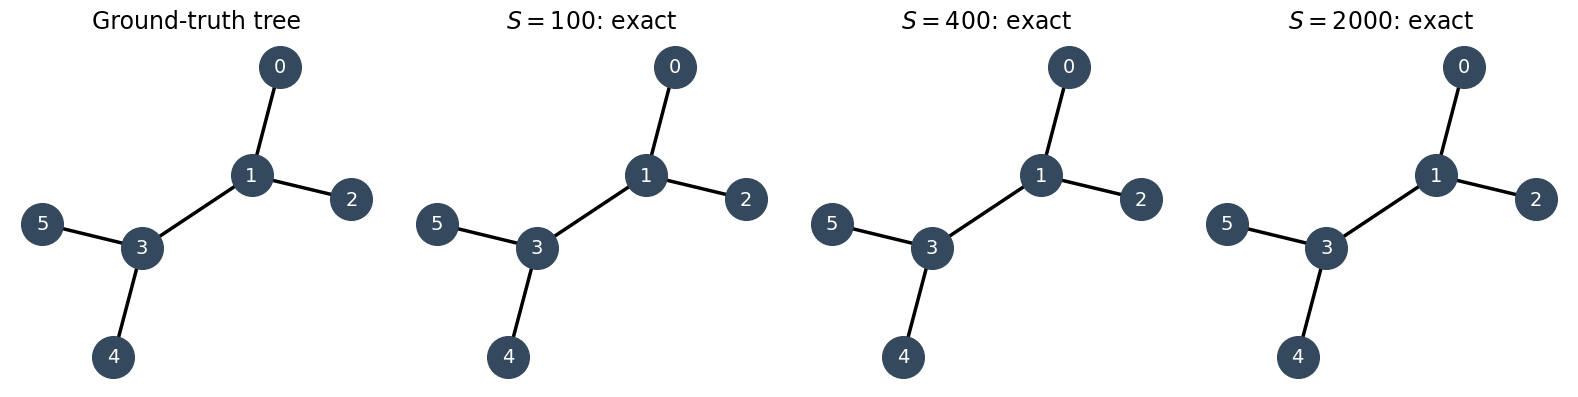

In [3]:
sizes=[100,400,2000]
pos=nx.spring_layout(nx.Graph(true_edges),seed=3)
fig,axes=plt.subplots(1,4,figsize=(16,4.2))
Gt=nx.Graph(true_edges)
nx.draw_networkx(Gt,pos,node_color=NODE_COLOR,font_color='white',font_size=14,node_size=900,width=2.5,ax=axes[0]); axes[0].set_title('Ground-truth tree'); axes[0].axis('off')
for ax,N in zip(axes[1:],sizes):
    T,_=chow_liu(sample(N)); good=set(map(frozenset,T.edges()))==set(map(frozenset,true_edges))
    nx.draw_networkx(T,pos,node_color=NODE_COLOR,font_color='white',font_size=14,node_size=900,width=2.5,ax=ax)
    ax.set_title(f'$S={N}$: '+('exact' if good else 'sampling error')); ax.axis('off')
fig.tight_layout(); save_figure(fig,'ch10_01_true_and_reconstructed_trees'); plt.show()

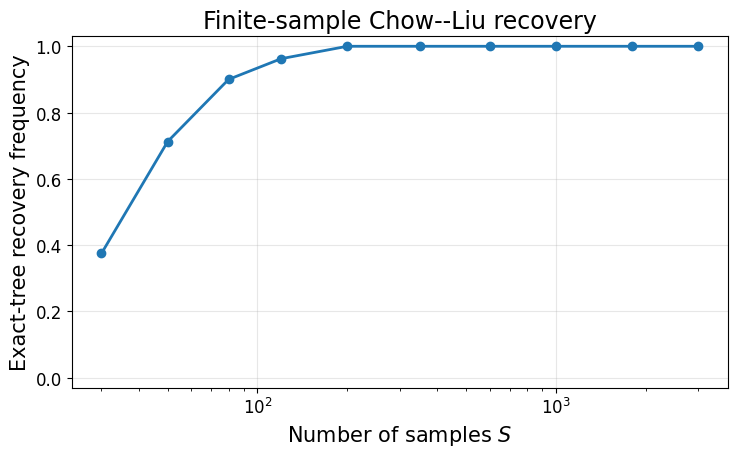

In [4]:
sample_sizes=np.array([30,50,80,120,200,350,600,1000,1800,3000])
trials=80; recovery=[]
truth=set(map(frozenset,true_edges))
for N in sample_sizes:
    ok=0
    for _ in range(trials):
        T,_=chow_liu(sample(int(N)))
        ok += set(map(frozenset,T.edges()))==truth
    recovery.append(ok/trials)
fig,ax=plt.subplots(figsize=(7.6,4.8)); ax.semilogx(sample_sizes,recovery,marker='o',linewidth=2)
ax.set_xlabel('Number of samples $S$'); ax.set_ylabel('Exact-tree recovery frequency'); ax.set_ylim(-.03,1.03); ax.grid(alpha=.3); ax.set_title('Finite-sample Chow--Liu recovery')
fig.tight_layout(); save_figure(fig,'ch10_01_recovery_vs_samples'); plt.show()

## Exercises

1. **Weak-edge experiment.** Reduce one coupling to $J=0.1$. How does the recovery curve change, and why?
2. **Misspecified model.** Add one extra interaction to create a loop. Chow--Liu still returns a tree. Compare the learned tree with the exact distribution using KL divergence.
3. **Prediction instead of structure.** Compare selected pairwise marginals under the learned tree and the true model. Can the learned tree be useful even when its edge set is wrong?